In [1]:
import sys
from pathlib import Path

ROOT = str(Path.cwd().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.data_loader import load_all_datasets
from src.config import COLUMN_NAMES, DATASETS, USEFUL_SENSORS, DROP_SENSORS

sns.set_theme(style="whitegrid")
data = load_all_datasets()

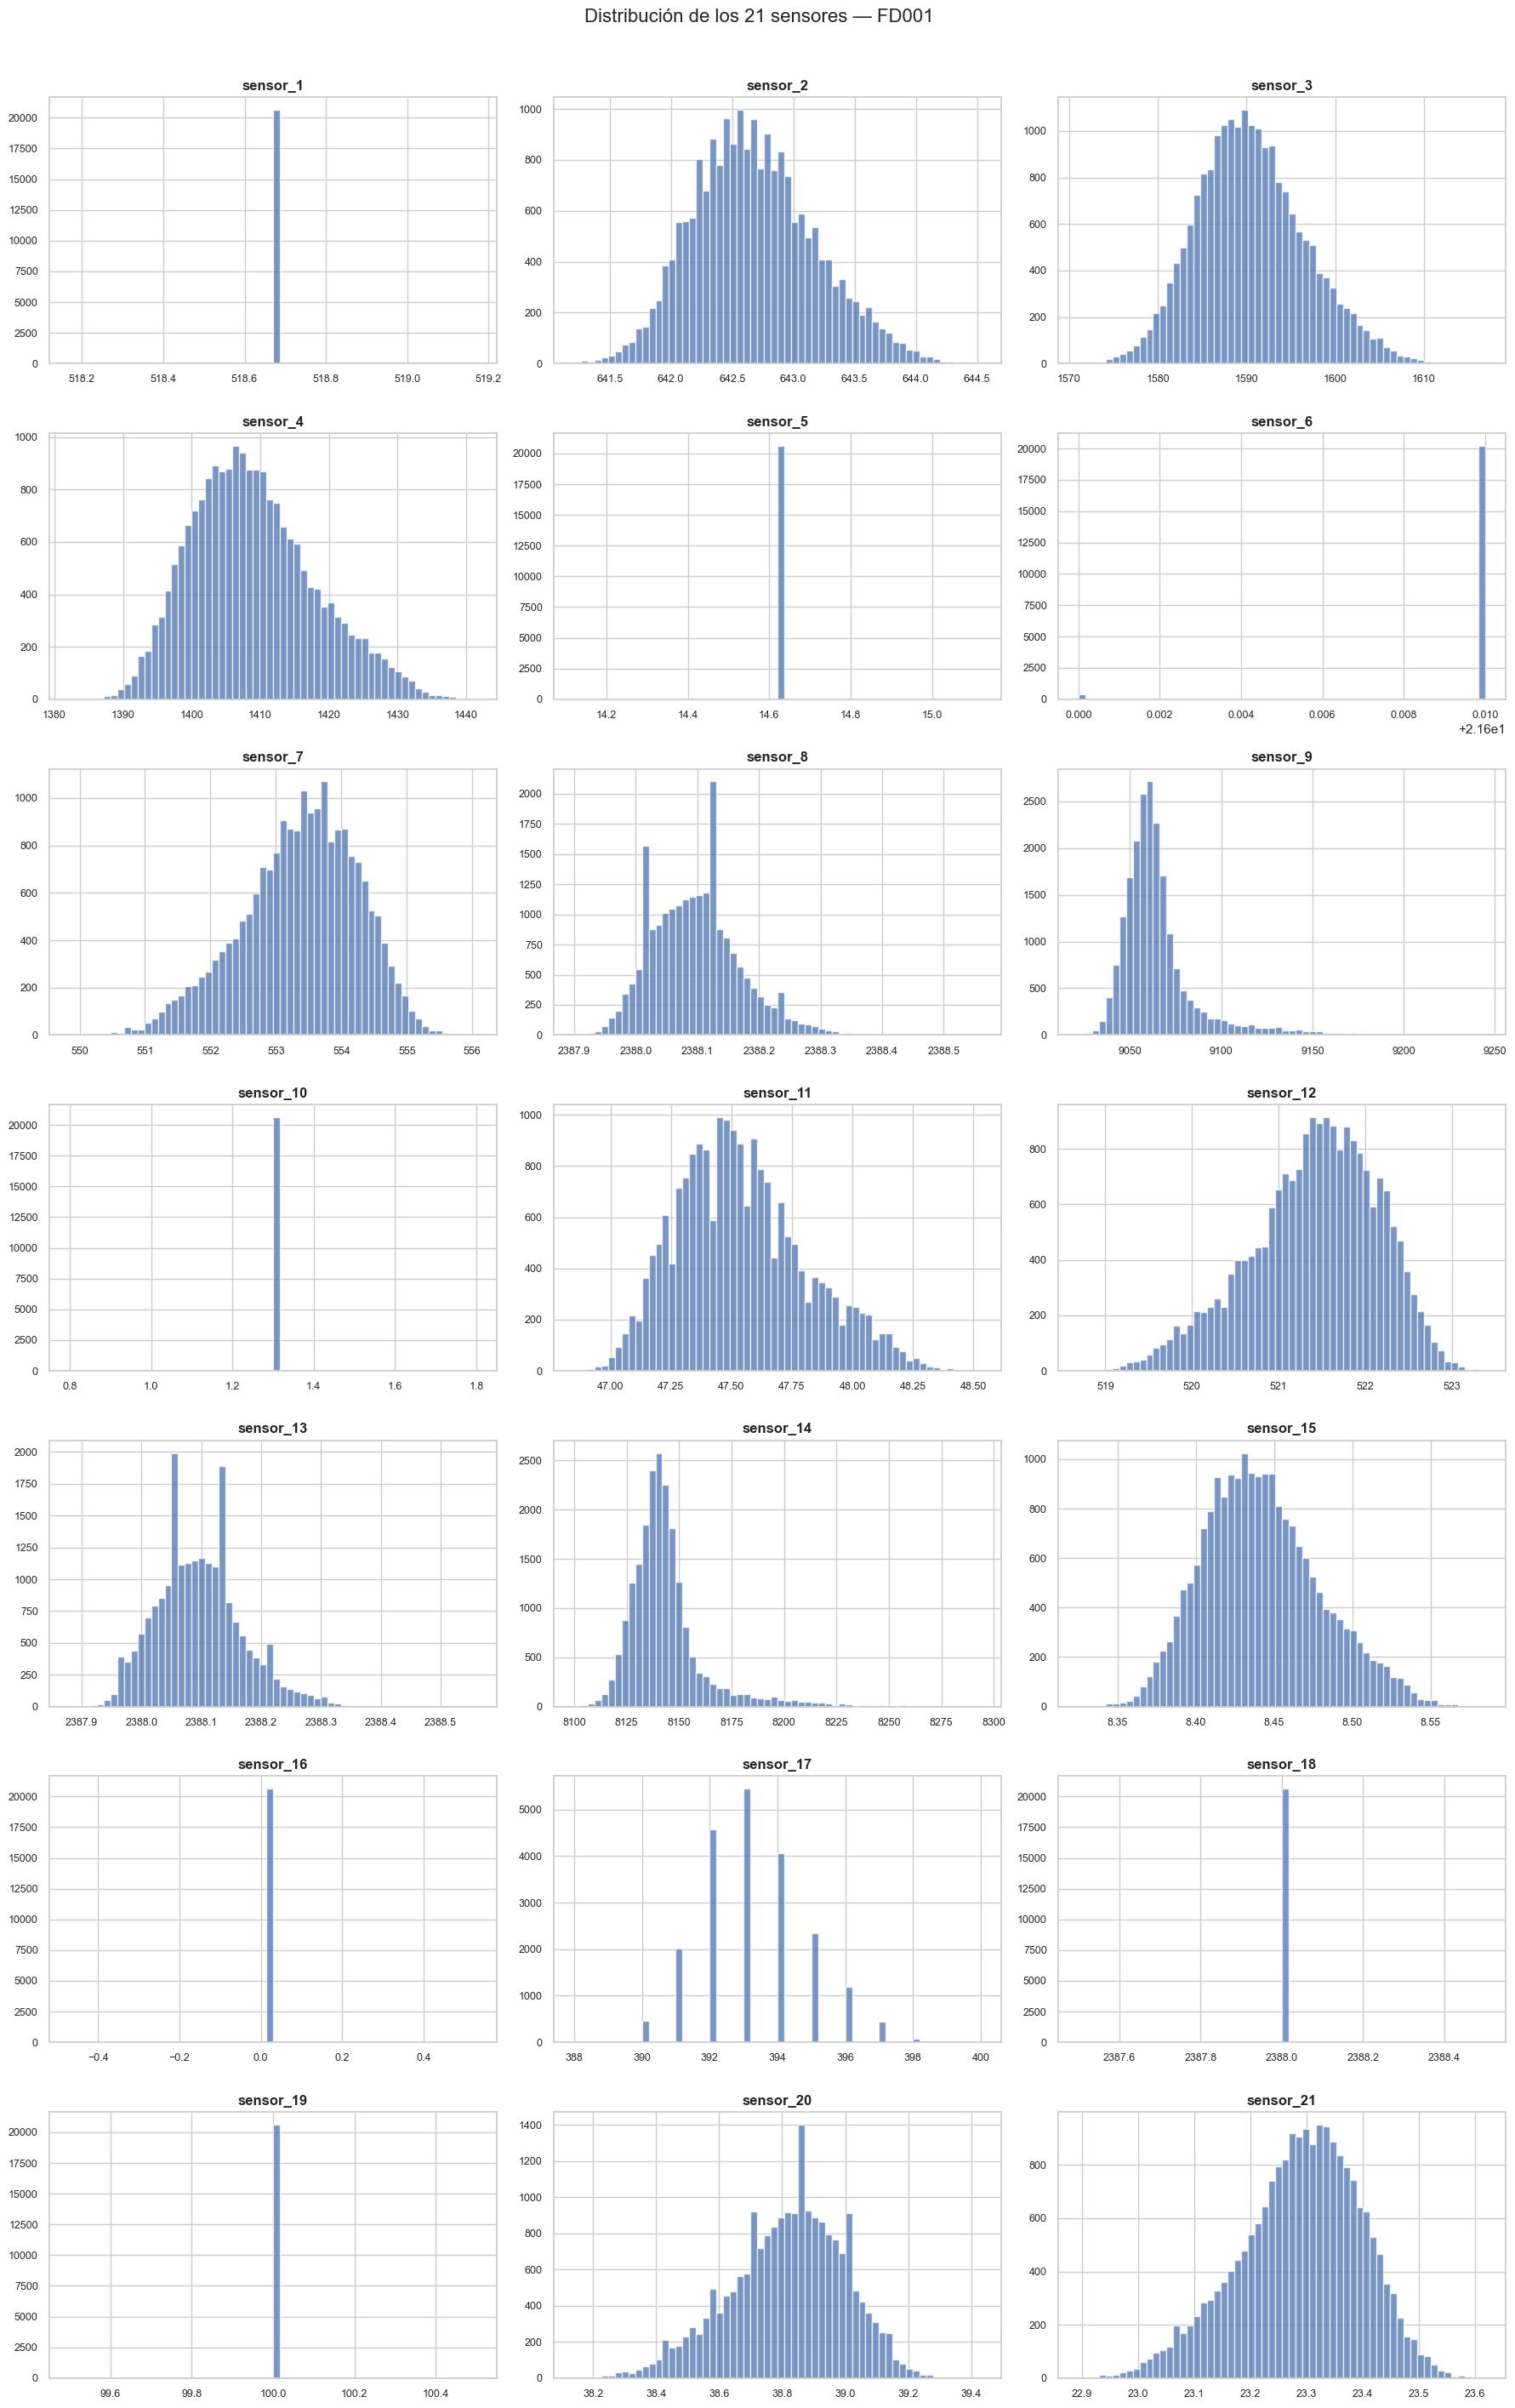

In [2]:
train = data["FD001"][0]
sensor_cols = [c for c in COLUMN_NAMES if c.startswith("sensor_")]

fig, axes = plt.subplots(7, 3, figsize=(18, 28))
axes = axes.flatten()

for i, sensor in enumerate(sensor_cols):
    axes[i].hist(train[sensor], bins=60, alpha=0.75, edgecolor="white", color="#4C72B0")
    axes[i].set_title(sensor, fontsize=12, fontweight="bold")
    axes[i].tick_params(labelsize=9)

plt.suptitle("Distribución de los 21 sensores — FD001", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

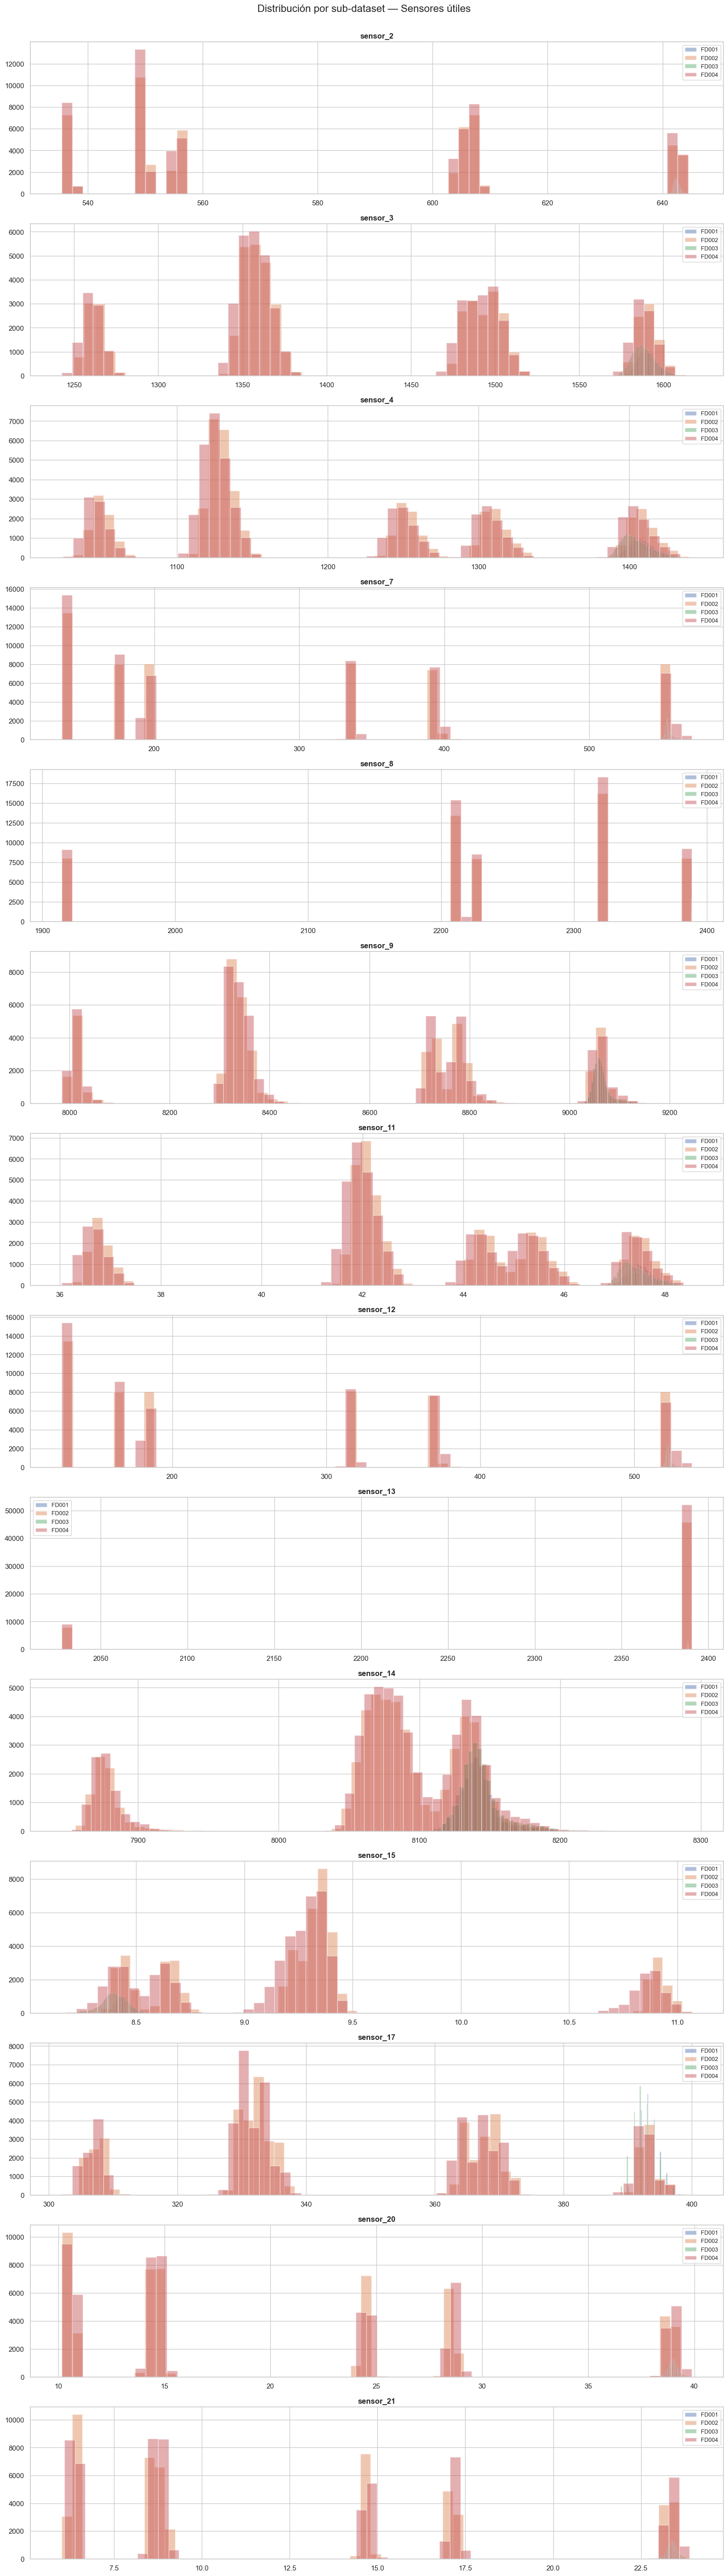

In [3]:
fig, axes = plt.subplots(len(USEFUL_SENSORS), 1, figsize=(16, 4 * len(USEFUL_SENSORS)))

for i, sensor in enumerate(USEFUL_SENSORS):
    for ds_id in DATASETS:
        train = data[ds_id][0]
        axes[i].hist(train[sensor], bins=60, alpha=0.45, label=ds_id, edgecolor="white")
    axes[i].set_title(sensor, fontsize=12, fontweight="bold")
    axes[i].legend(fontsize=9)

plt.suptitle("Distribución por sub-dataset — Sensores útiles", fontsize=16, y=1.001)
plt.tight_layout()
plt.show()

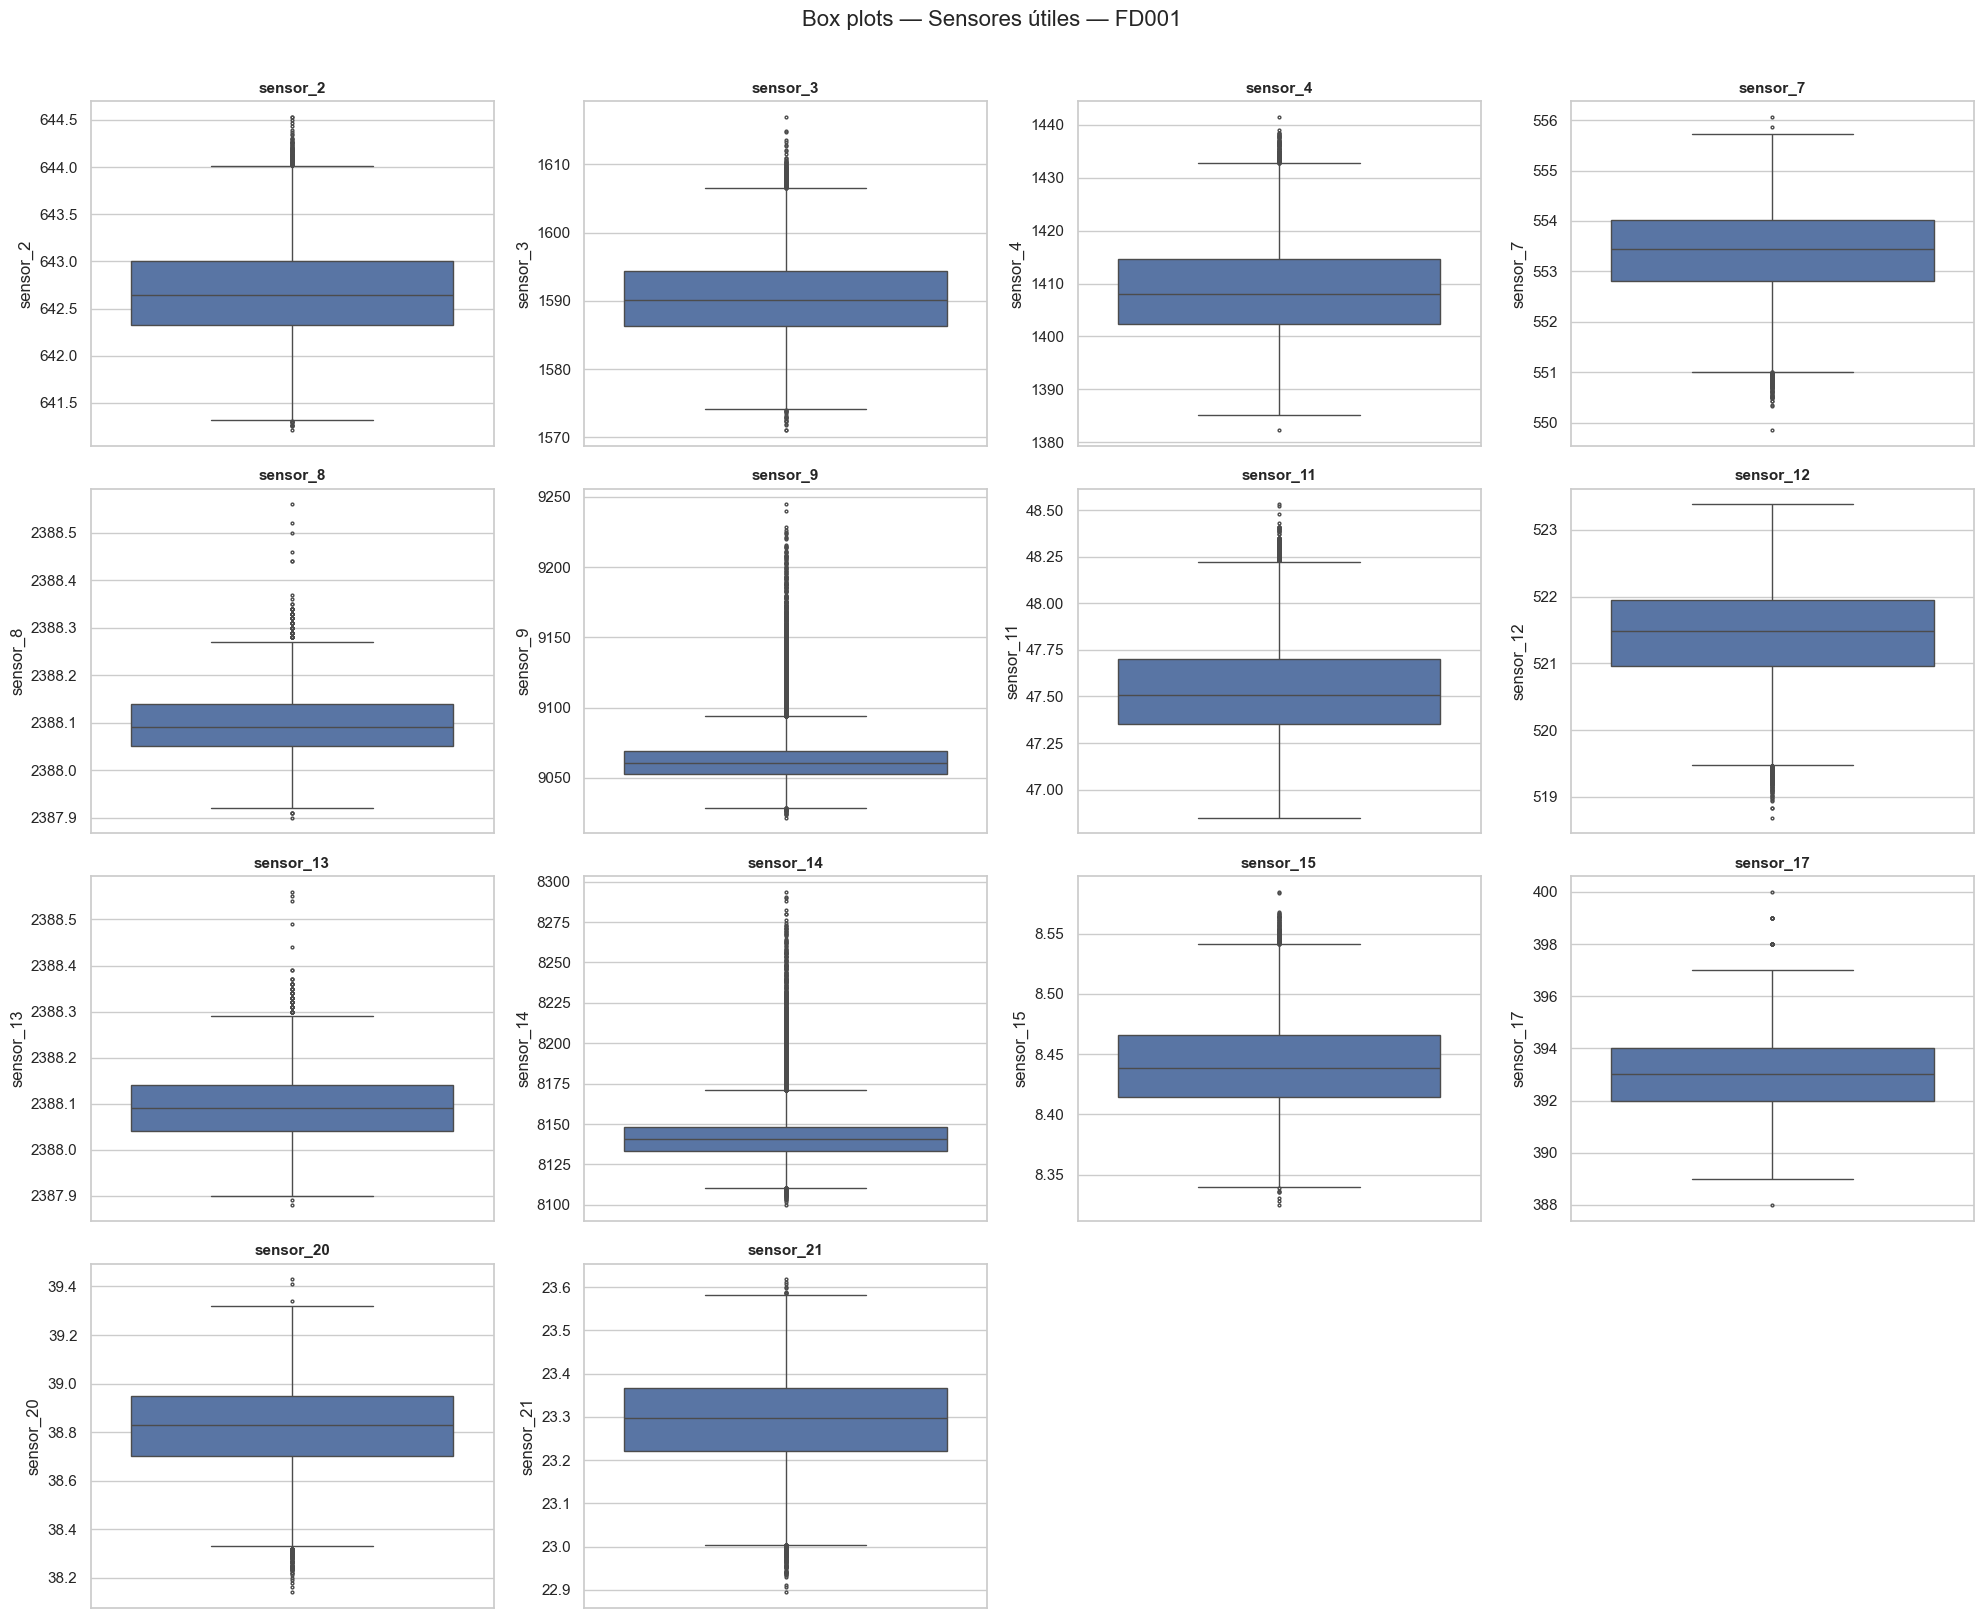

In [4]:
train = data["FD001"][0]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, sensor in enumerate(USEFUL_SENSORS[:16]):
    sns.boxplot(data=train, y=sensor, ax=axes[i], color="#4C72B0", fliersize=2)
    axes[i].set_title(sensor, fontsize=11, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Box plots — Sensores útiles — FD001", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

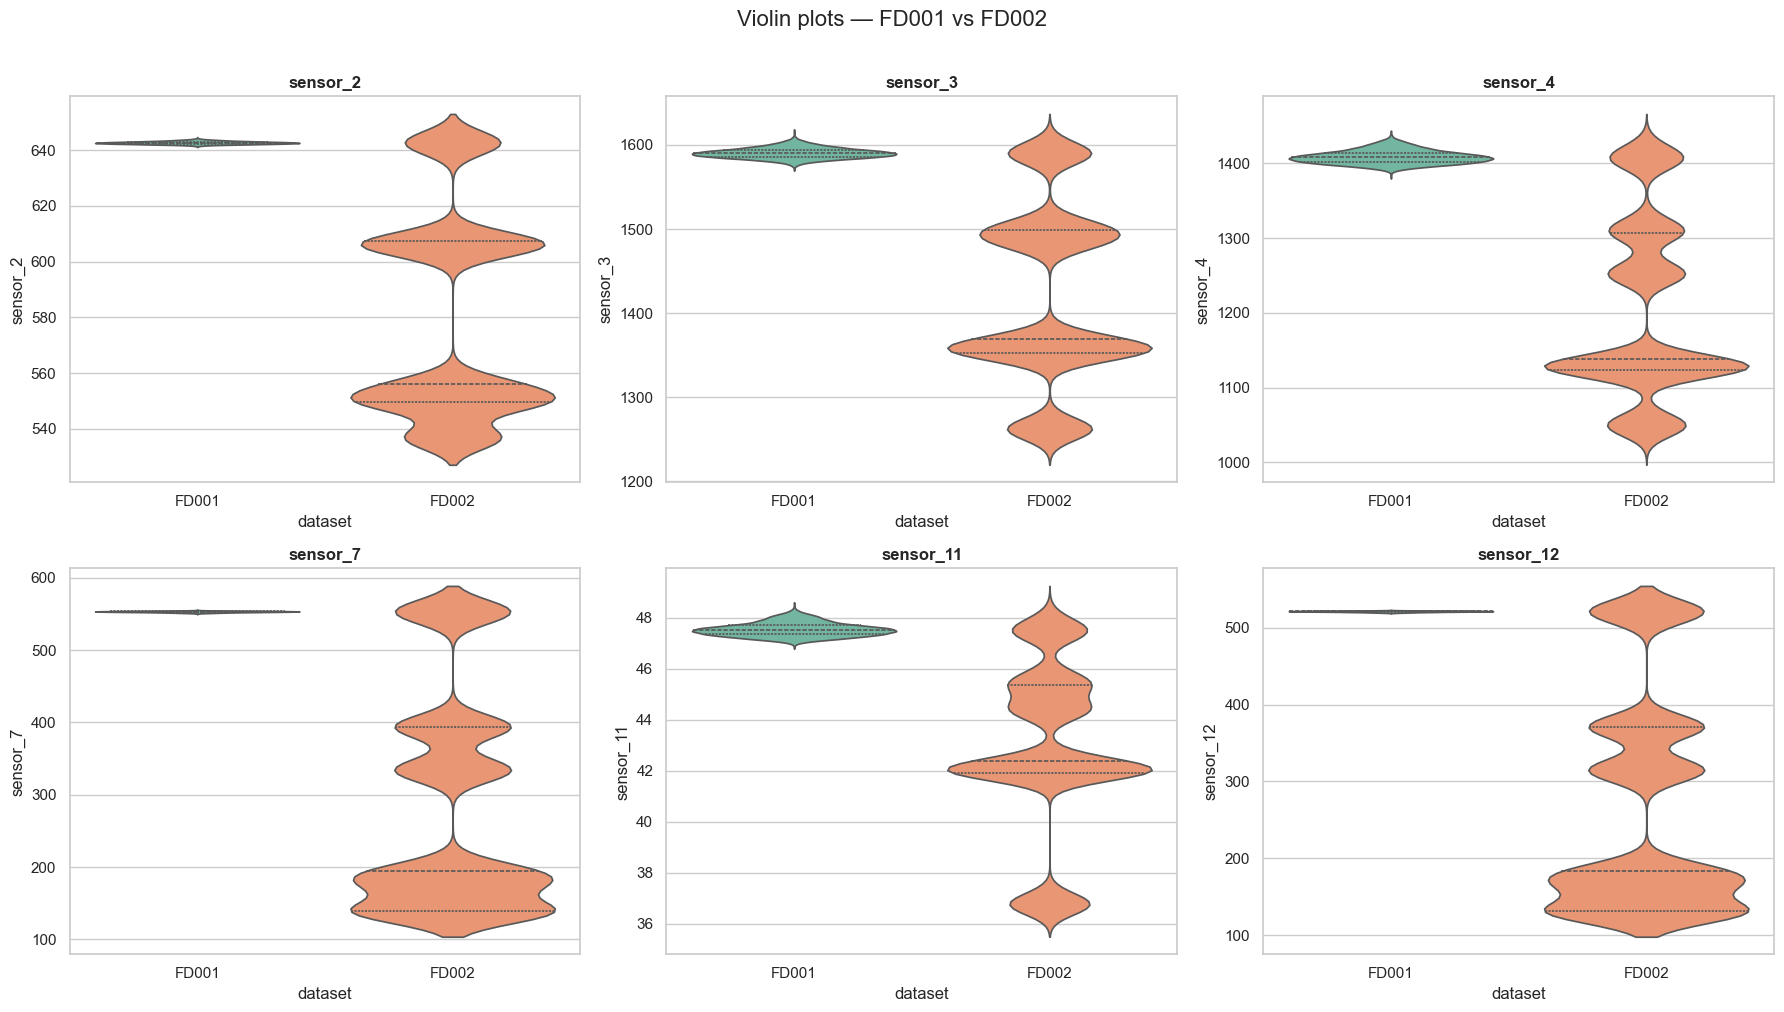

In [13]:
top_sensors = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_11", "sensor_12"]

fd001 = data["FD001"][0][top_sensors].assign(dataset="FD001")
fd002 = data["FD002"][0][top_sensors].assign(dataset="FD002")
combined = pd.concat([fd001, fd002], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    sns.violinplot(data=combined, x="dataset", y=sensor, hue="dataset", ax=axes[i], palette="Set2", inner="quartile", legend=False)
    axes[i].set_title(sensor, fontsize=12, fontweight="bold")

plt.suptitle("Violin plots — FD001 vs FD002", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

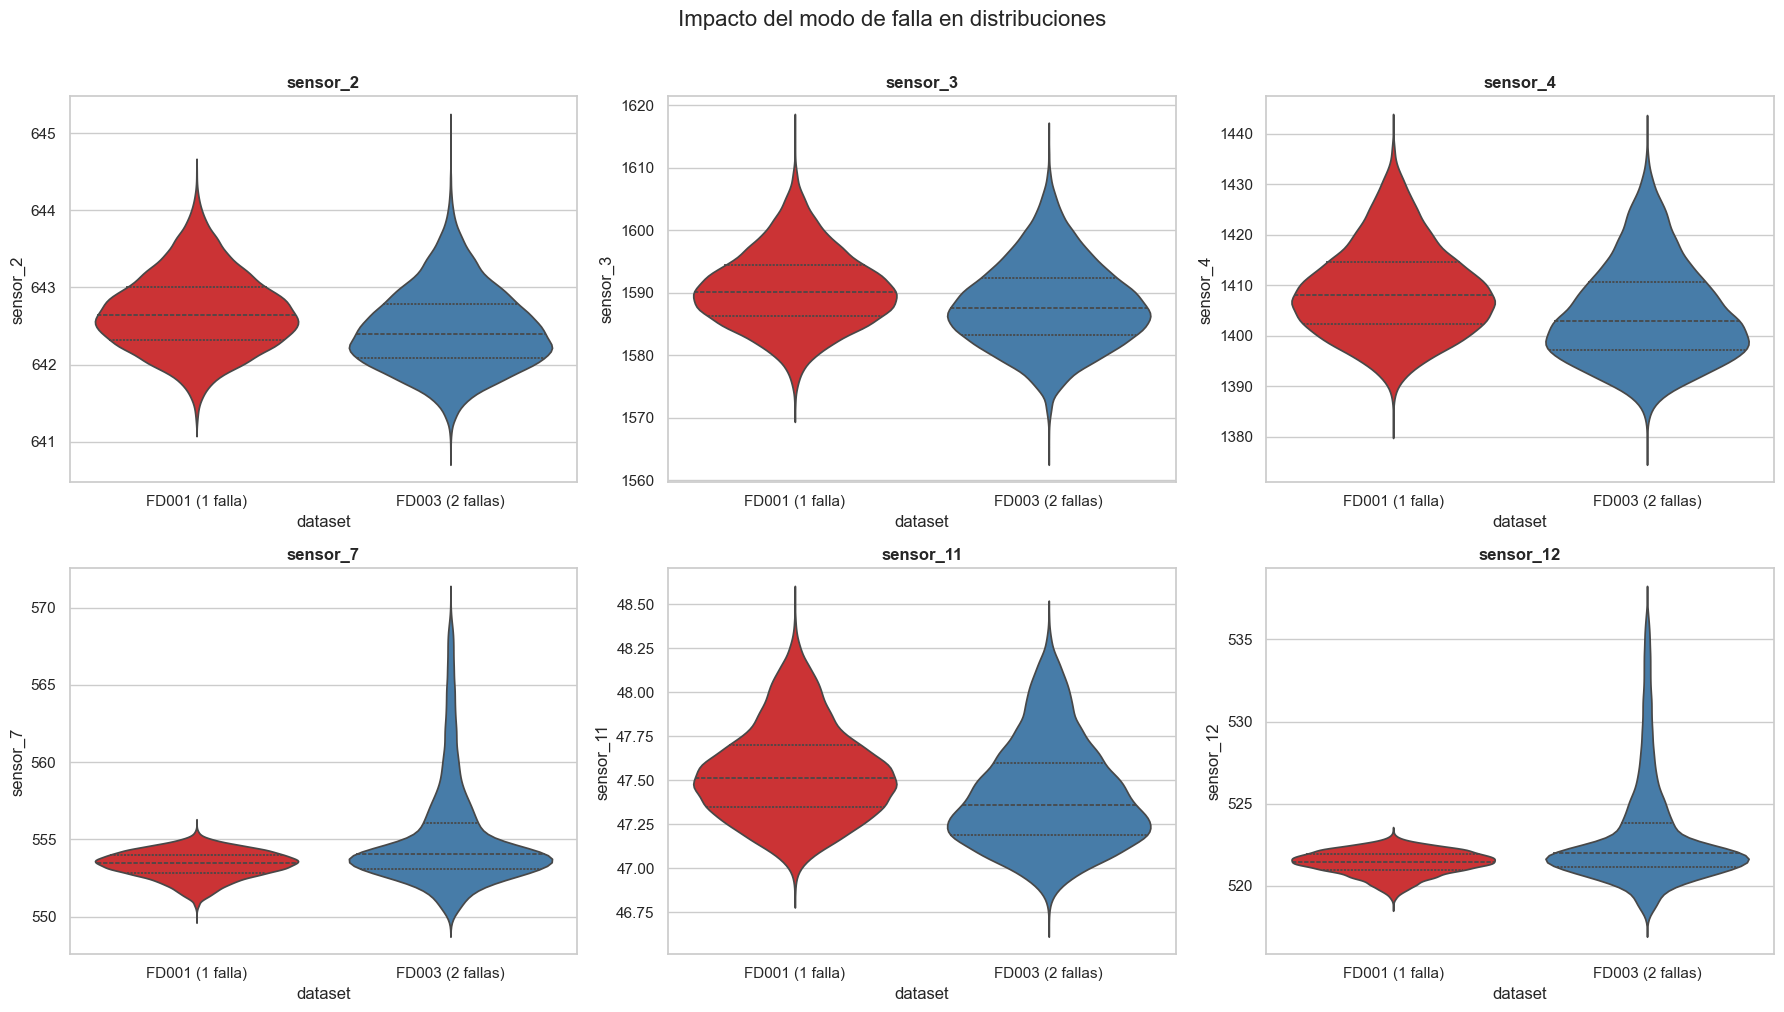

In [14]:
fd001 = data["FD001"][0][top_sensors].assign(dataset="FD001 (1 falla)")
fd003 = data["FD003"][0][top_sensors].assign(dataset="FD003 (2 fallas)")
combined = pd.concat([fd001, fd003], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    sns.violinplot(data=combined, x="dataset", y=sensor, hue="dataset", ax=axes[i], palette="Set1", inner="quartile", legend=False)
    axes[i].set_title(sensor, fontsize=12, fontweight="bold")

plt.suptitle("Impacto del modo de falla en distribuciones", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

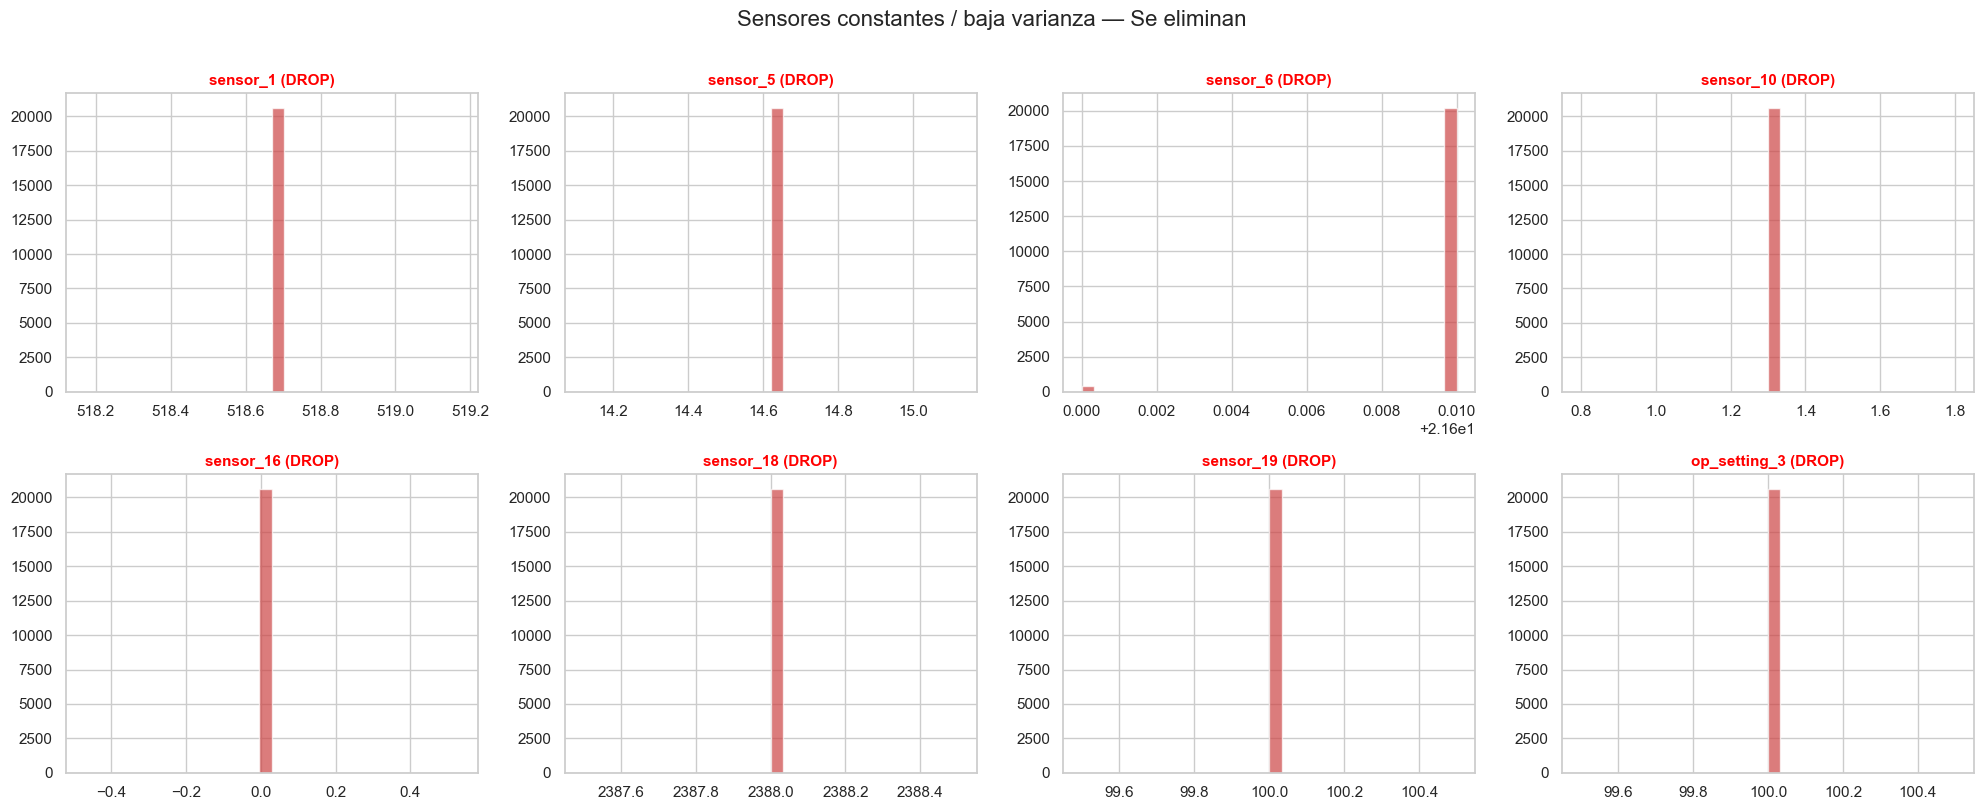

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

all_drop = DROP_SENSORS + ["op_setting_3"]

for i, sensor in enumerate(all_drop):
    if i < len(axes):
        train = data["FD001"][0]
        axes[i].hist(train[sensor], bins=30, color="#CC4444", alpha=0.7, edgecolor="white")
        axes[i].set_title(f"{sensor} (DROP)", fontsize=11, fontweight="bold", color="red")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Sensores constantes / baja varianza — Se eliminan", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
sensor = "sensor_11"

fig = go.Figure()
colors = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA"]

for ds_id, color in zip(DATASETS, colors):
    train = data[ds_id][0]
    fig.add_trace(go.Histogram(
        x=train[sensor],
        name=ds_id,
        opacity=0.55,
        marker_color=color,
        nbinsx=80,
    ))

fig.update_layout(
    title=f"Distribución de {sensor} — 4 sub-datasets",
    barmode="overlay",
    xaxis_title=sensor,
    yaxis_title="Frecuencia",
    template="plotly_white",
    height=500,
)
fig.show()

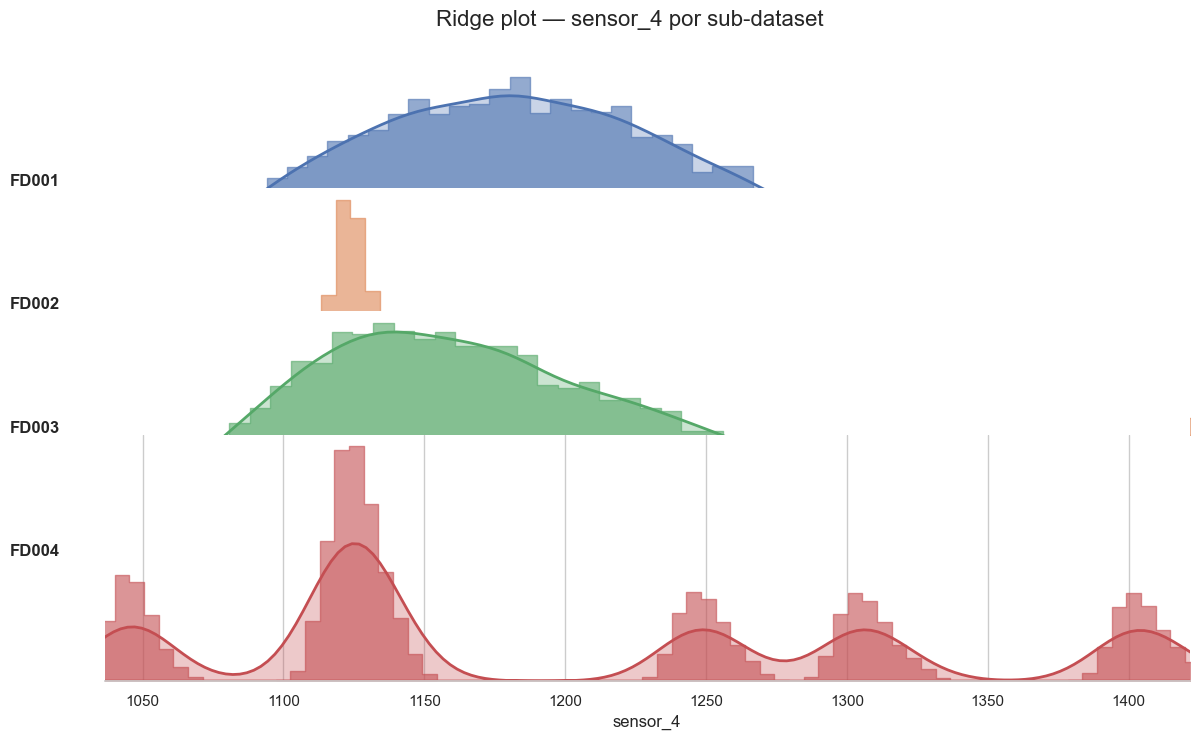

In [15]:
from matplotlib.gridspec import GridSpec

sensor = "sensor_4"
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(4, 1, hspace=-0.5)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, ds_id in enumerate(DATASETS):
    ax = fig.add_subplot(gs[i, 0])
    train = data[ds_id][0]
    counts, bin_edges = np.histogram(train[sensor], bins=80, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.fill_between(bin_centers, counts, alpha=0.6, color=colors[i], step="mid")
    sns.kdeplot(data=train, x=sensor, ax=ax, color=colors[i], linewidth=2, fill=True, alpha=0.3)
    ax.set_ylabel(ds_id, fontsize=12, fontweight="bold", rotation=0, labelpad=50)
    ax.set_xlim(train[sensor].quantile(0.01), train[sensor].quantile(0.99))
    ax.set_yticks([])
    if i < 3:
        ax.set_xticks([])
        ax.spines["bottom"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

plt.suptitle(f"Ridge plot — {sensor} por sub-dataset", fontsize=16, y=0.95)
plt.show()

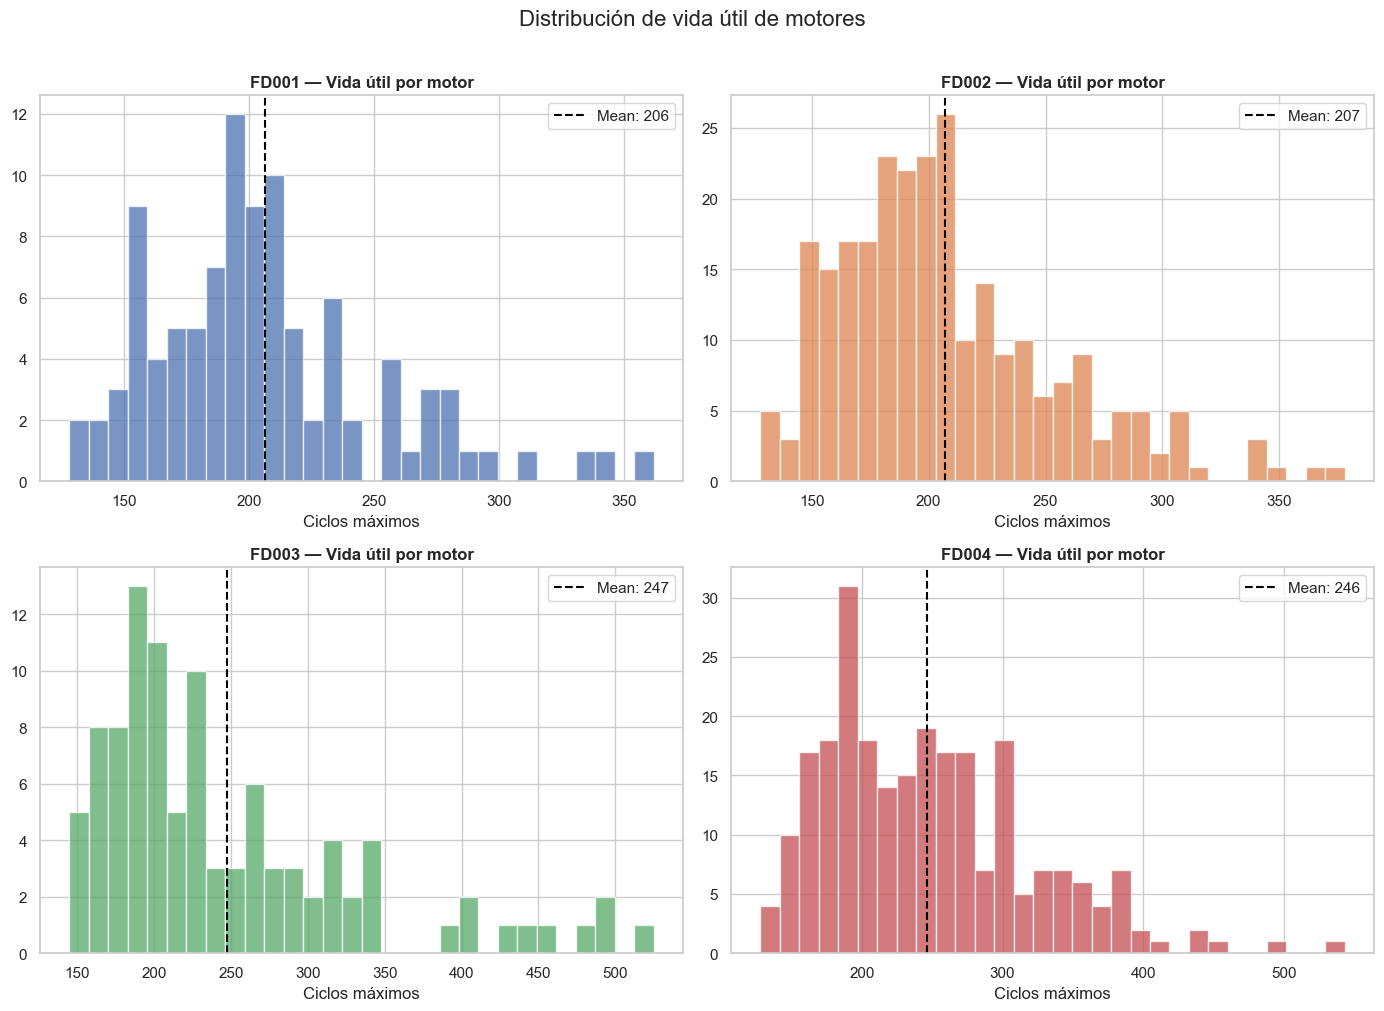

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, ds_id in enumerate(DATASETS):
    train = data[ds_id][0]
    max_cycles = train.groupby("unit_id")["cycle"].max()
    axes[i].hist(max_cycles, bins=30, color=colors[i], alpha=0.75, edgecolor="white")
    axes[i].axvline(max_cycles.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean: {max_cycles.mean():.0f}")
    axes[i].set_title(f"{ds_id} — Vida útil por motor", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Ciclos máximos")
    axes[i].legend()

plt.suptitle("Distribución de vida útil de motores", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
train_fd002 = data["FD002"][0]

fig = px.scatter_3d(
    train_fd002.drop_duplicates(subset=["op_setting_1", "op_setting_2", "op_setting_3"]),
    x="op_setting_1",
    y="op_setting_2",
    z="op_setting_3",
    color="op_setting_1",
    title="Condiciones operacionales — FD002 (6 clusters)",
    template="plotly_white",
    height=600,
)
fig.update_traces(marker=dict(size=6))
fig.show()

In [12]:
stats_rows = []
for ds_id in DATASETS:
    train = data[ds_id][0]
    for sensor in USEFUL_SENSORS:
        stats_rows.append({
            "dataset": ds_id,
            "sensor": sensor,
            "mean": train[sensor].mean(),
            "std": train[sensor].std(),
            "min": train[sensor].min(),
            "max": train[sensor].max(),
            "skew": train[sensor].skew(),
            "kurtosis": train[sensor].kurtosis(),
        })

stats_df = pd.DataFrame(stats_rows)

fig = px.bar(
    stats_df,
    x="sensor",
    y="std",
    color="dataset",
    barmode="group",
    title="Desviación estándar por sensor y sub-dataset",
    template="plotly_white",
    height=500,
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [1]:
import sys
from pathlib import Path
import zipfile

ROOT = str(Path.cwd().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

output_zip = Path(ROOT) / "all_figures.zip"

image_extensions = {".png", ".jpg", ".jpeg", ".svg", ".pdf"}
folders_to_search = [
    Path(ROOT) / "paper" / "figures",
]

with zipfile.ZipFile(output_zip, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in folders_to_search:
        if folder.exists():
            for f in folder.rglob("*"):
                if f.suffix.lower() in image_extensions:
                    zf.write(f, f"figures/{f.name}")
                    print(f"  + {f.name}")

print(f"\n✓ ZIP creado: {output_zip}")
print(f"  Tamaño: {output_zip.stat().st_size / 1024:.1f} KB")


✓ ZIP creado: c:\Users\OEM\Desktop\Proyectos personales\NASA_C-MAPSS_Data\all_figures.zip
  Tamaño: 0.0 KB
